# EDA

### Importación de librerías.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

### Importación de datos.

In [2]:
df = pd.read_excel('HotelData.xlsx')
df.head(3)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled


### Observando tipos de datos y si hay faltantes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25811 entries, 0 to 25810
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          25811 non-null  int64  
 1   no_of_children                        25811 non-null  int64  
 2   no_of_weekend_nights                  25811 non-null  int64  
 3   no_of_week_nights                     25811 non-null  int64  
 4   type_of_meal_plan                     25811 non-null  object 
 5   required_car_parking_space            25811 non-null  int64  
 6   lead_time                             25811 non-null  int64  
 7   arrival_year                          25811 non-null  int64  
 8   arrival_month                         25811 non-null  int64  
 9   arrival_date                          25811 non-null  int64  
 10  repeated_guest                        25811 non-null  int64  
 11  no_of_previous_

Se tienen muchos datos, lo cual nos ayudará a tener mejores modelos.
No contamos con datos faltantes y casi todos son numéricos, por lo que se profundizará en los valores tipo object.

### Estadísticas de los datos

In [4]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000
mean,1.890744,0.142265,0.883034,2.263918,0.042424,65.548836,2017.850490,7.331099,15.752780,0.033009,0.028747,0.214676,105.747677,0.746426
std,0.529264,0.464034,0.887990,1.514417,0.201558,67.452796,0.356597,3.143281,8.854341,0.178664,0.410378,2.075722,37.916084,0.815896
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,12.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.750000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,44.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,100.000000,1.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,98.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,127.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


Las columnas no_of_weekend_nights, no_of_week_nights, lead_time, no_of_previous_cancellations, no_of_previous_bookings_not_canceled, avg_price_per_room y no_of_special_requests tienen presencia de datos atípicos. No se realizará ningún tratamiento a estos debido a que los modelos que se usarán no son sensibles a datos atípicos.

### Valores únicos de variables categóricas.

In [5]:
df['type_of_meal_plan'].value_counts().to_frame()

,count
type_of_meal_plan,
Meal Plan 1,20265
Not Selected,4463
Meal Plan 2,1078
Meal Plan 3,5


In [6]:
df['booking_status'].value_counts().to_frame()

,count
booking_status,
Not_Canceled,18542
Canceled,7269


Las etiquetas están desbalanceadas, lo cual se tendrá en cuenta al momento de dividir el conjunto de datos.

### Codificación de valores categóricos.

In [7]:
# Columnas categóricas.
columnas_categoricas = ['type_of_meal_plan', 'booking_status']

# Crear el encoder.
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop=[['Meal Plan 3'], ['Not_Canceled']])

# Entrenar y aplicar la transformación
encoded_array = encoder.fit_transform(df[columnas_categoricas])

# Crear DataFrame con nombres consistentes
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(columnas_categoricas), index=df.index)

# Eliminar columnas originales y agregar nuevas
df2 = pd.concat([df.drop(columns=columnas_categoricas), encoded_df], axis=1)

df2.head(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,booking_status_Canceled
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1.0,0.0,0.0,0.0
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0.0,0.0,1.0,0.0


### Histogramas.

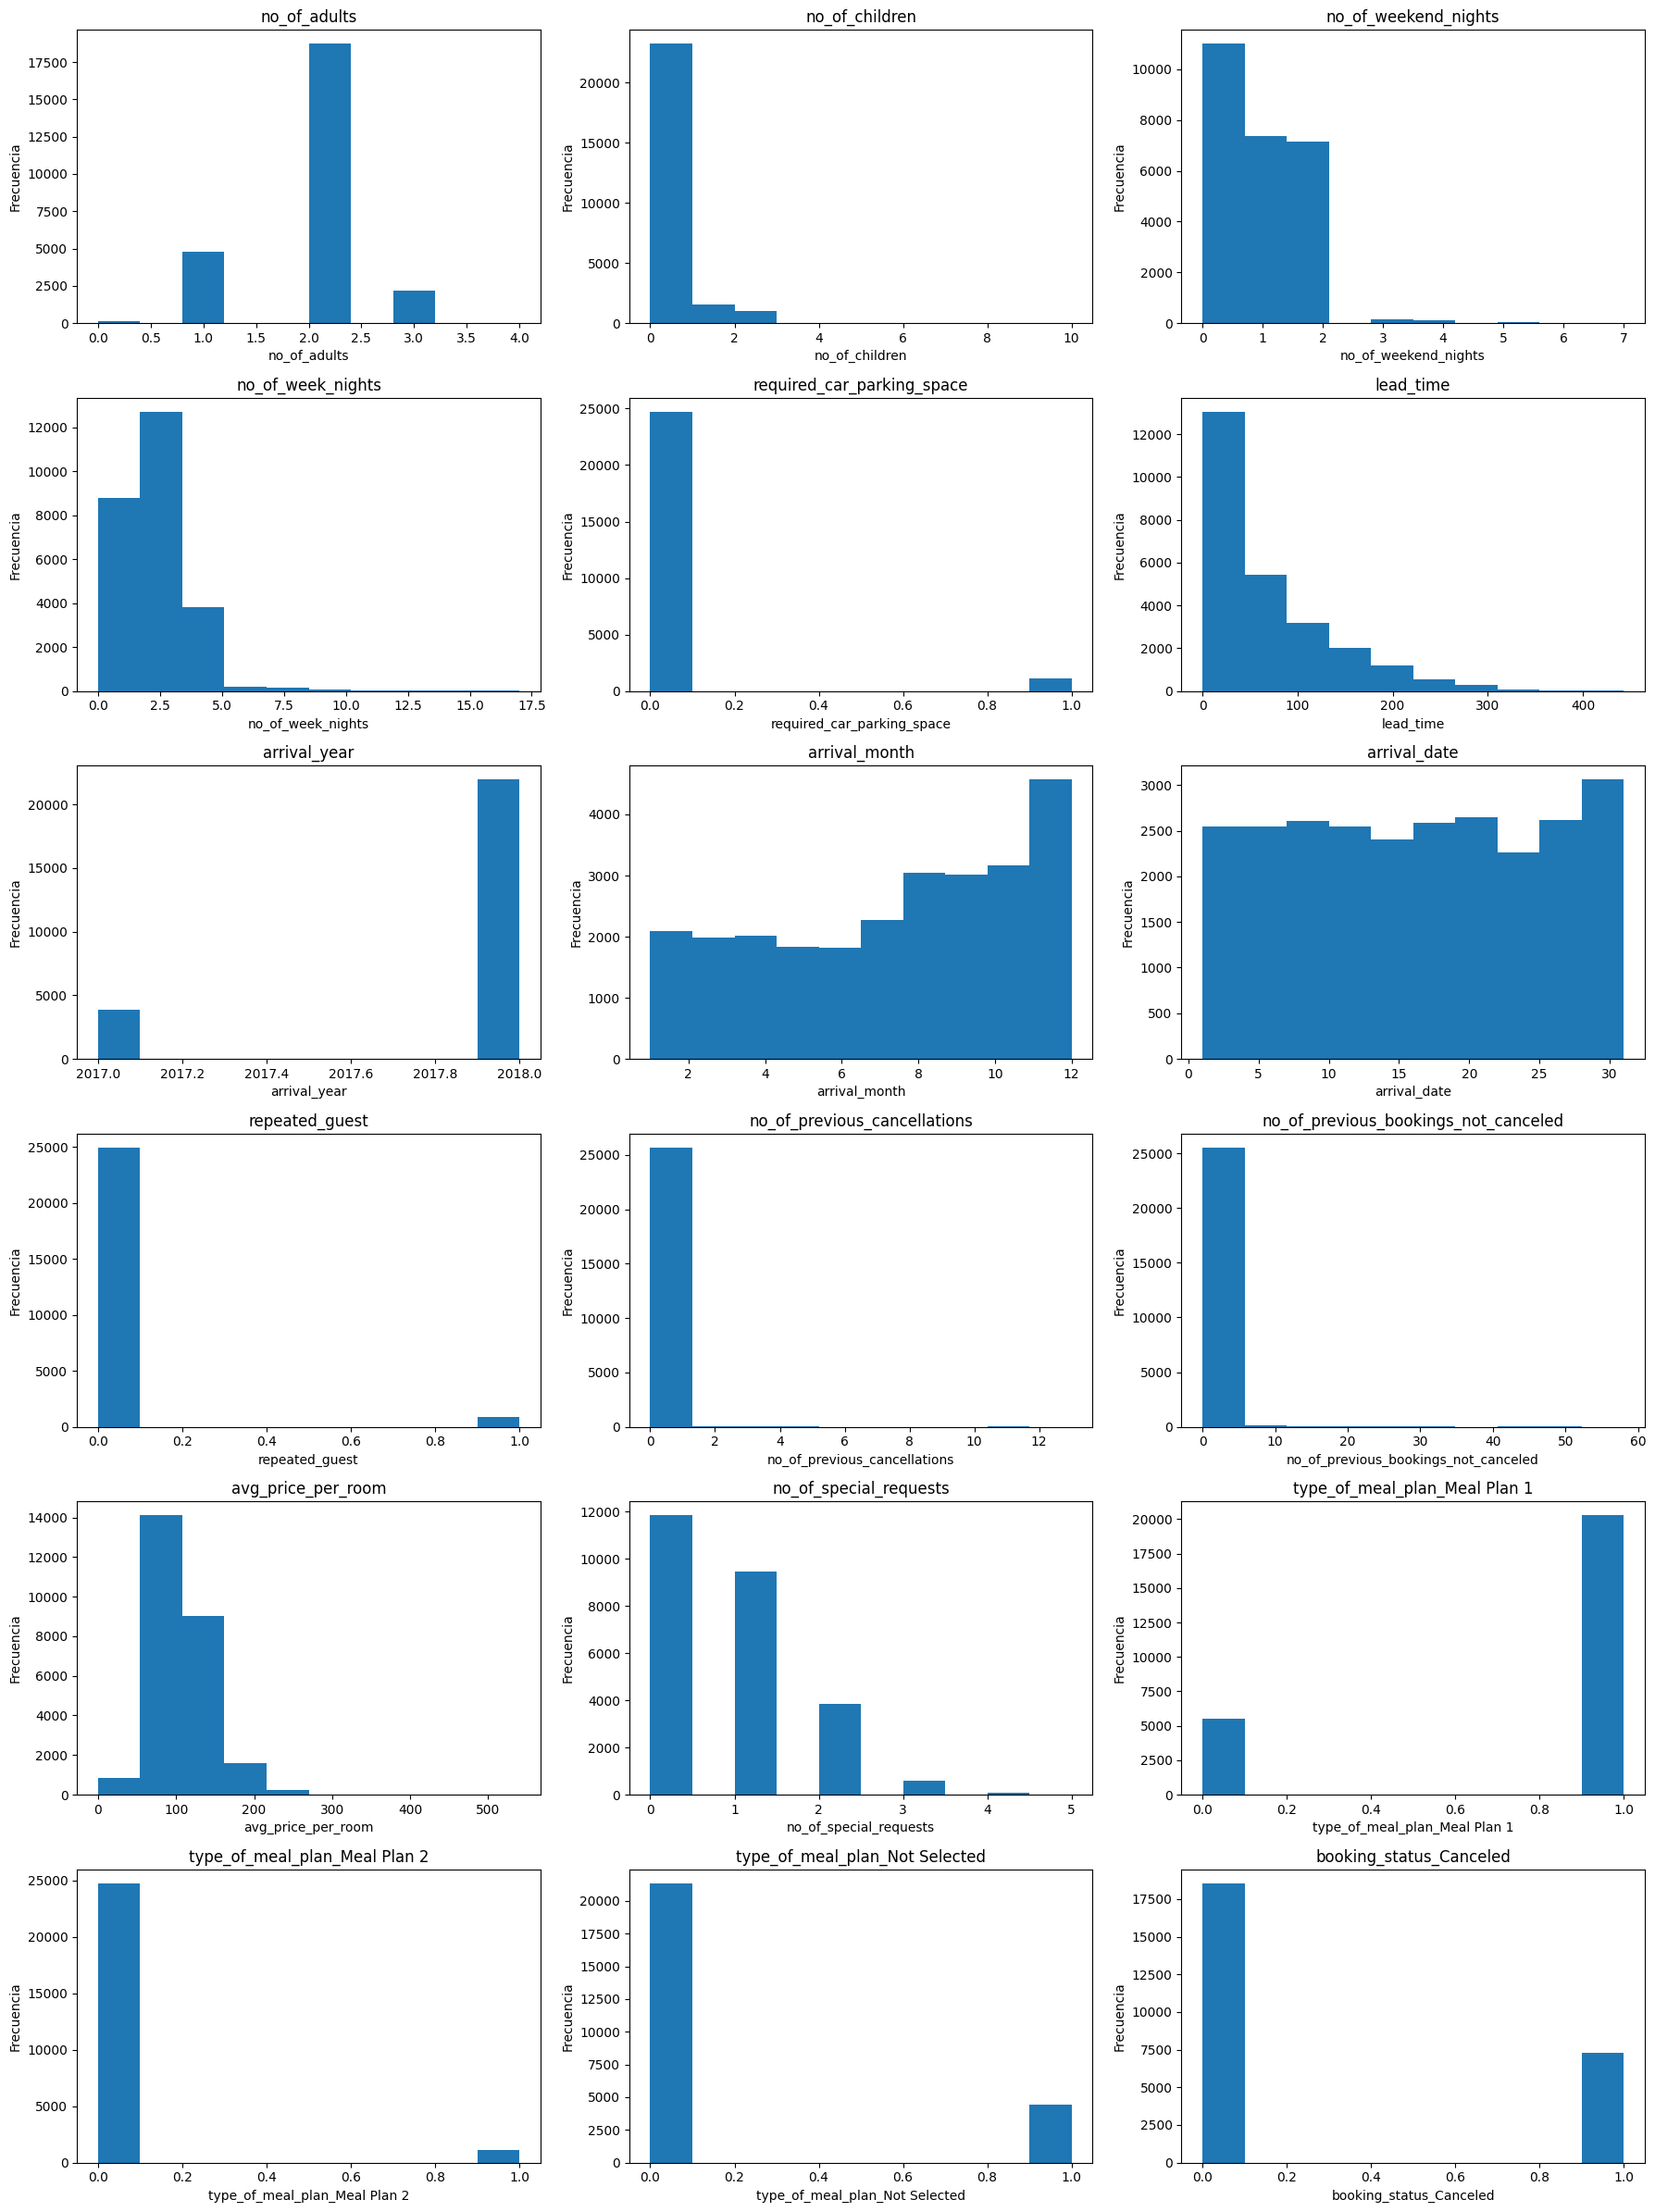

In [8]:
# Crear figura con 6 filas y 3 columnas.
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 24))

# Convertir matriz de ejes a vector.
axes = axes.flatten()

# Graficar histogramas
for i, columna in enumerate(df2.columns):
    axes[i].hist(df2[columna].dropna())
    axes[i].set_title(columna)
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se observa que solo avg_price_per_room tiene una distribución cercana a la normal.

### Comportamiento de las variables respecto a la etiqueta objetivo.

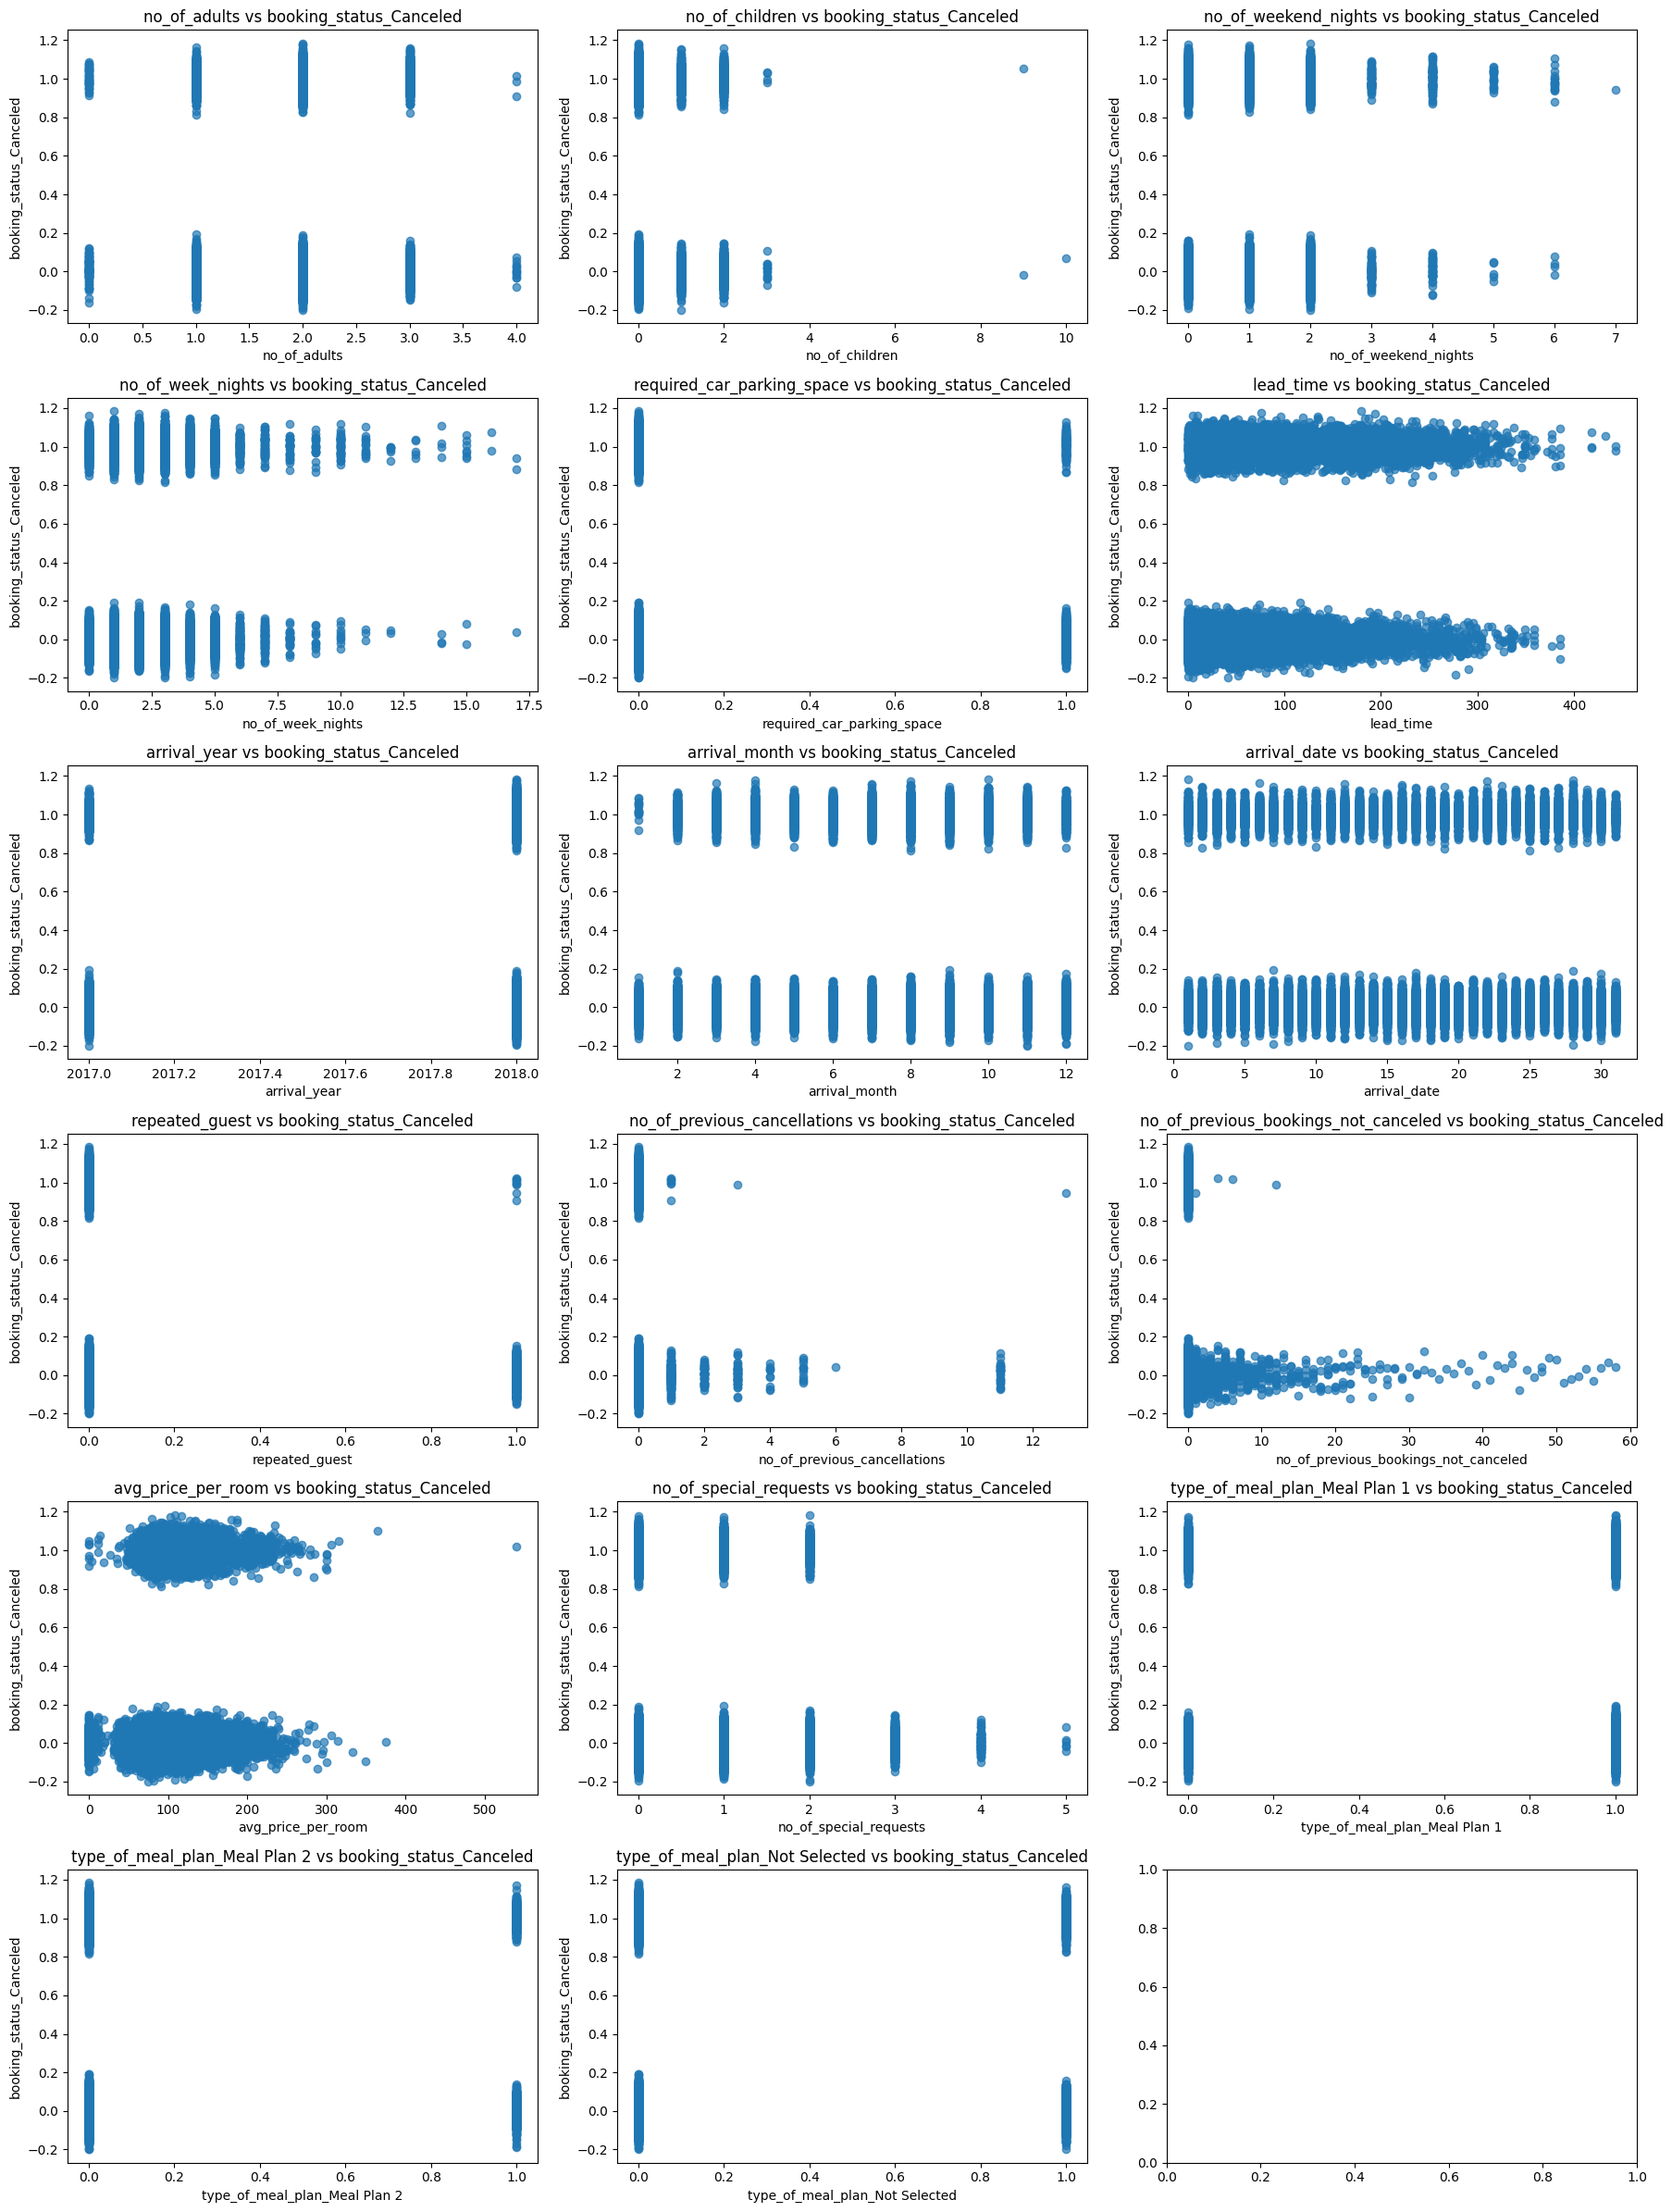

In [9]:
# Variable fija para eje Y
y_col =  'booking_status_Canceled'
y = df2[y_col]
y_jitter = y + np.random.normal(loc=0, scale=0.05, size = len(y))

# Variables para eje X
x_cols = [col for col in df2.columns if col != y_col]

# Figura
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 24))
axes = axes.flatten()

# Scatter plots
for i, col in enumerate(x_cols):

    axes[i].scatter(df2[col], y_jitter, alpha=0.7)
    axes[i].set_title(f"{col} vs {y_col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(y_col)

plt.tight_layout()
plt.show()

Muchas variables no muestran capacidad de separar las etiquetas de cancelación.
Las más prometedoras que se visualizan en los gráficos de arriba son no_of_previous_bookings_not_canceled, no_of_special_requests y avg_price_per_room. 

### Convertir el Data Frame a csv.

In [11]:
#df2.to_csv('DATOS.csv', index= False)